<a href="https://colab.research.google.com/github/aatayo/aatayo.github.io/blob/main/P3_Finite_Difference_Method_(FDM)_Solver_for_Cooling_Fin_Heat_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Finite Difference Method — Aluminum Cooling Fin (1D and 2D)
Thermal diffusivity α = 8.2305e-05 m²/s

PART 1: 1D FINITE DIFFERENCE SOLVER

[1D FDM] Grid: nx=201, Δx=0.0050 m
[1D FDM] Time step: Δt=0.1215 s, r=0.4000 (stable if <0.5)
[1D FDM] Total time steps: 8230
[1D FDM] Solved in 5.96s

Generating 1D visualizations...


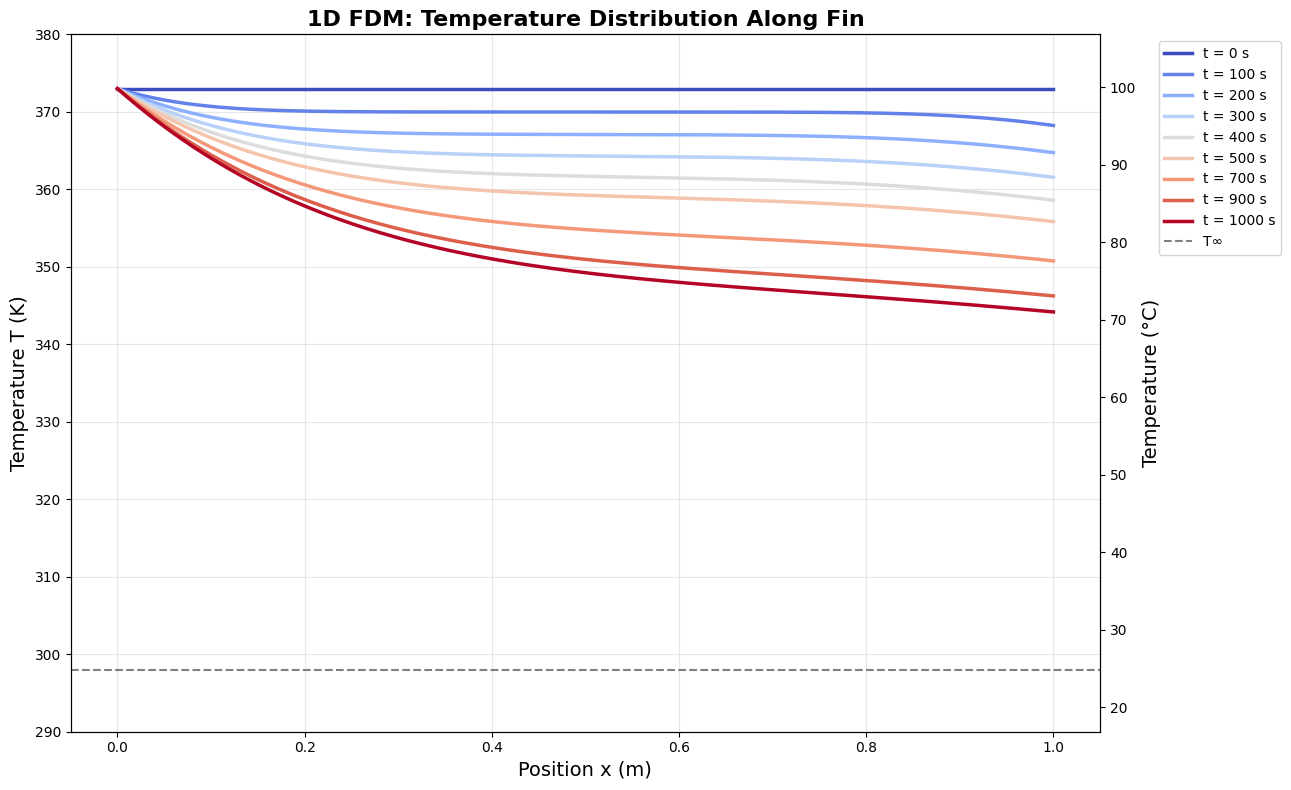

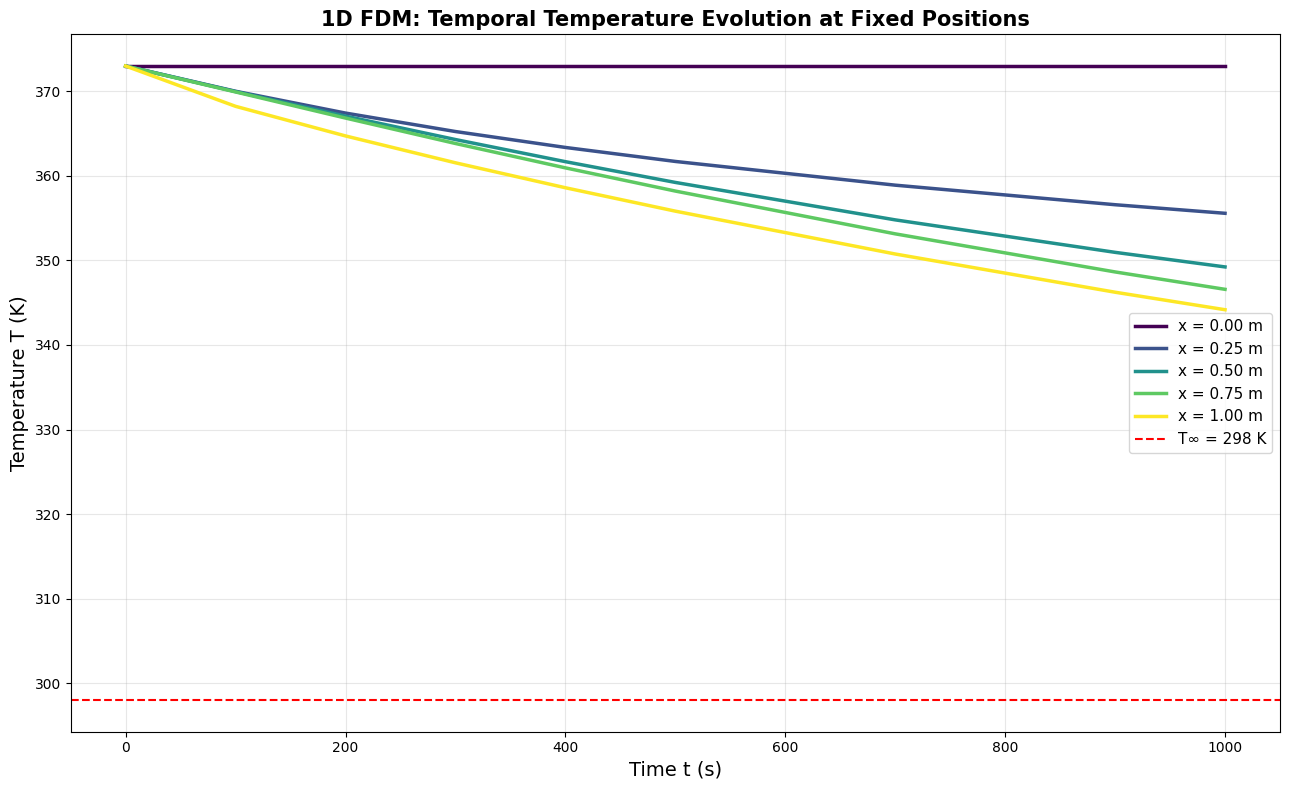

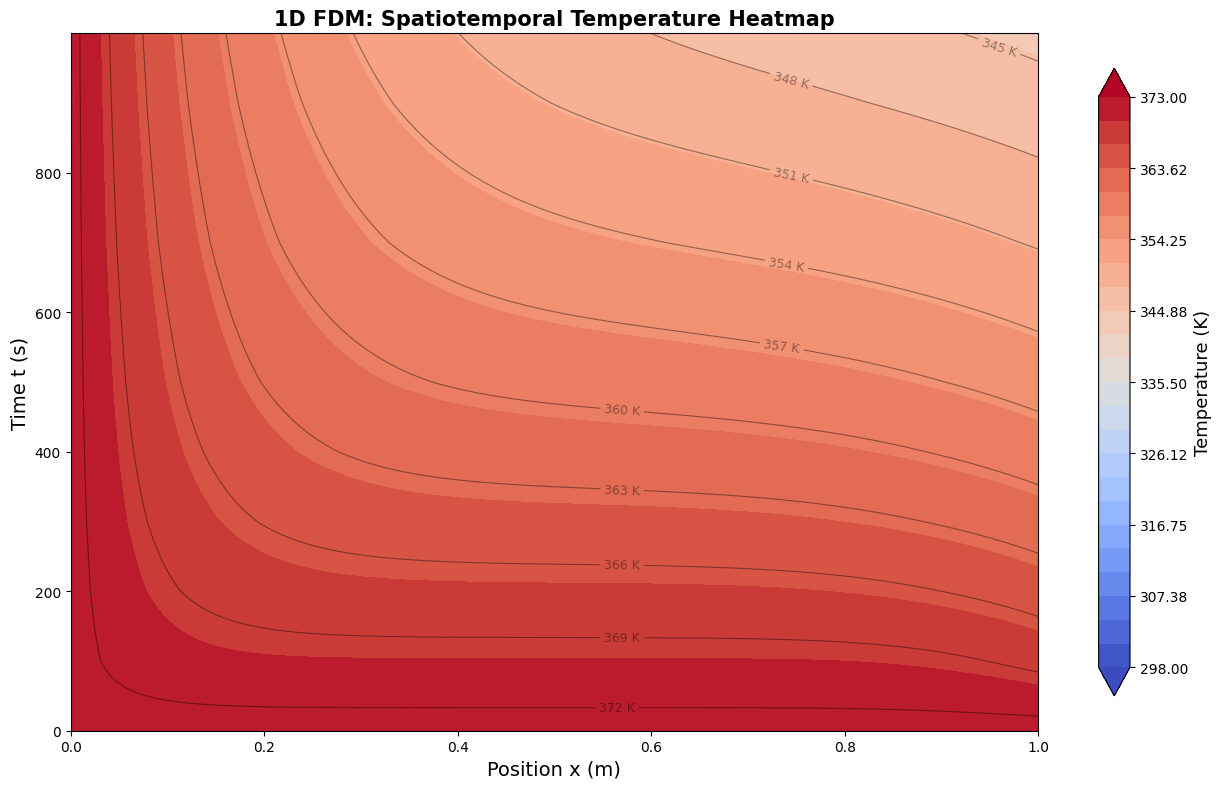

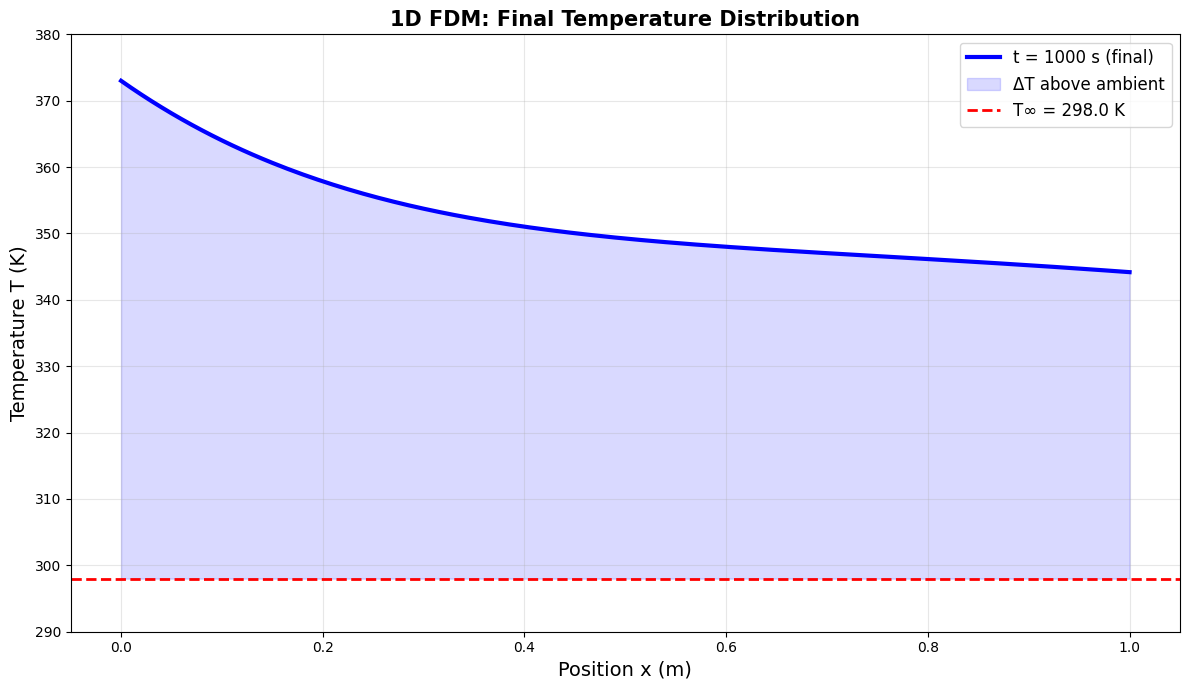


1D FDM HEAT TRANSFER ANALYSIS
Biot number       Bi = 0.2500
Fourier number    Fo = 0.08
Time constant     τ  = 2430.0 s

Final state (t = 1000 s):
  Base temperature (x=0) : 373.00 K  (99.85°C)
  Tip temperature  (x=L) : 344.17 K  (71.02°C)
  Average temperature    : 352.04 K  (78.89°C)
  Base-to-tip drop       : 28.83 K
  Fin effectiveness      : 0.7205
  Cooling efficiency     : 27.95%

PART 2: 2D FINITE DIFFERENCE SOLVER

[2D FDM] Grid: 101×21, Δx=0.0100 m, Δy=0.00500 m
[2D FDM] Δt=0.097200 s, rx=0.0800, ry=0.3200
[2D FDM] Stability parameter rx+ry = 0.4000 (must be <0.5)
[2D FDM] Total time steps: 10288
[2D FDM] Solved in 0.70s

Generating 2D visualizations...


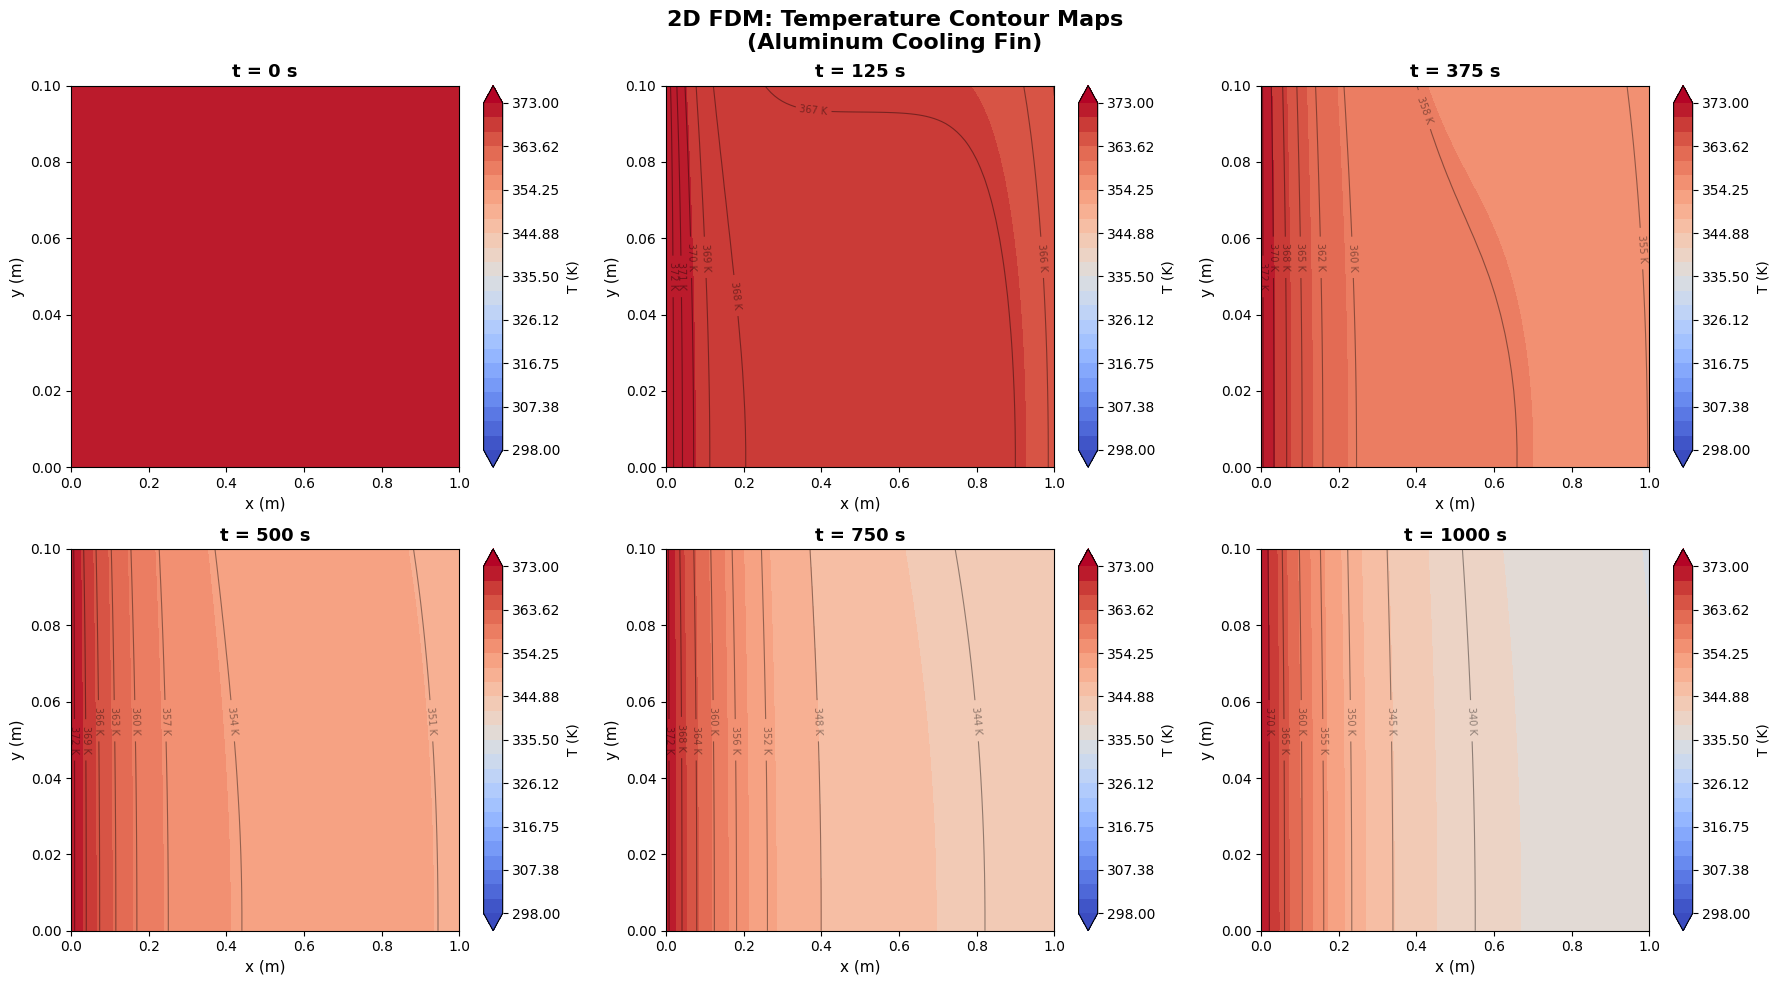

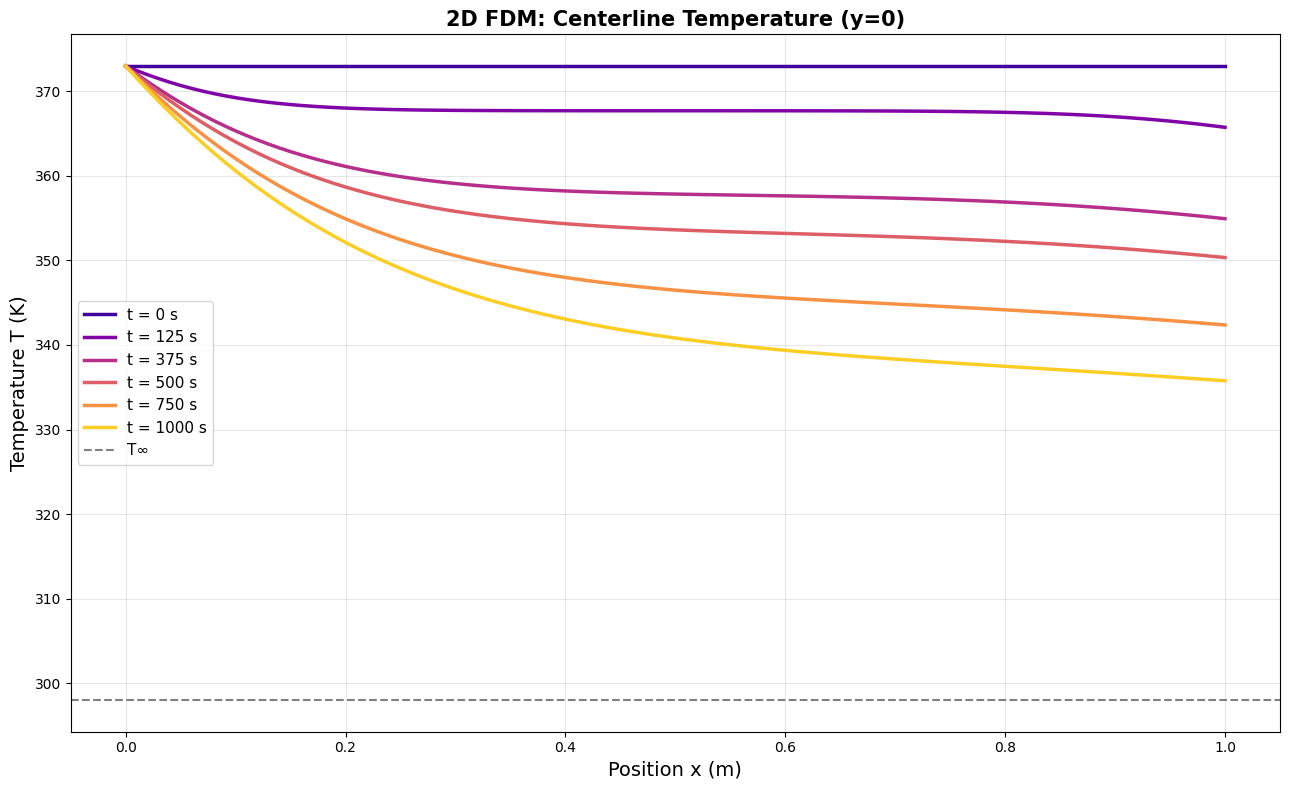

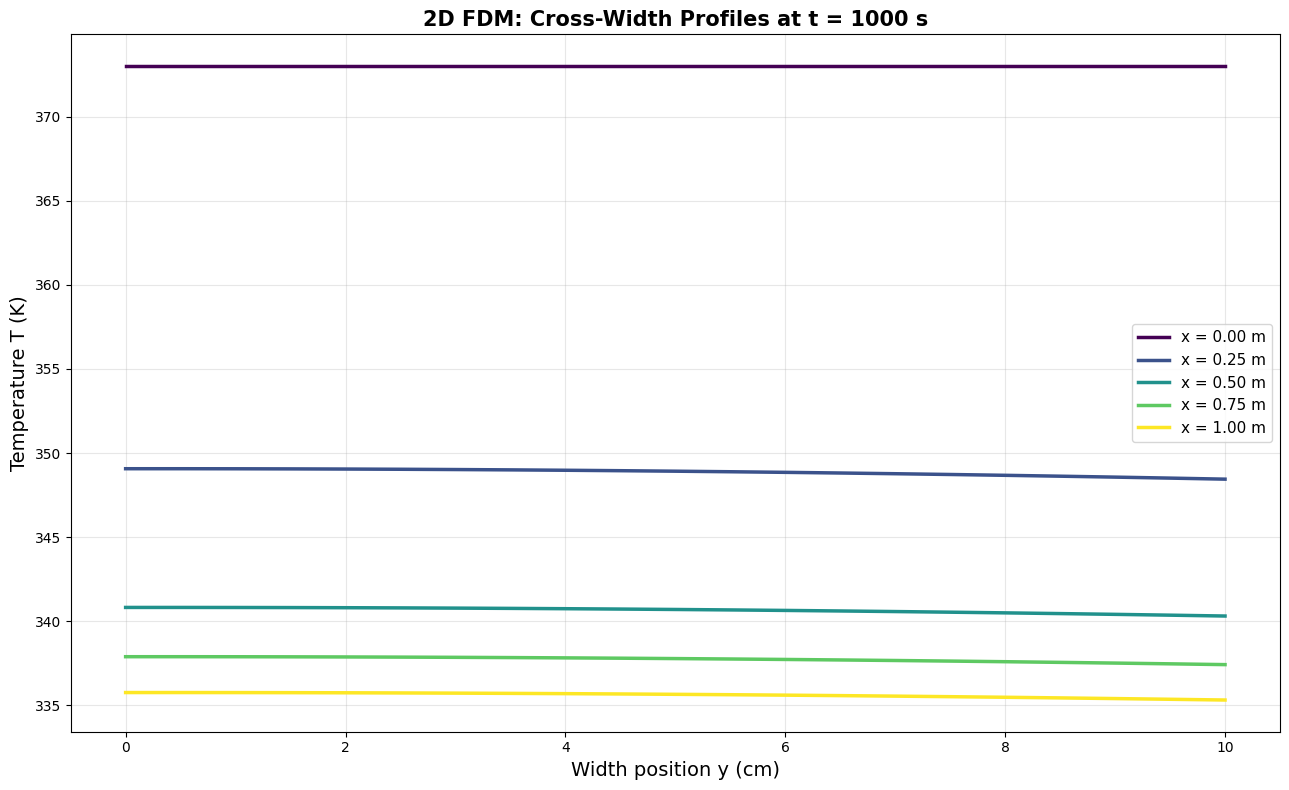

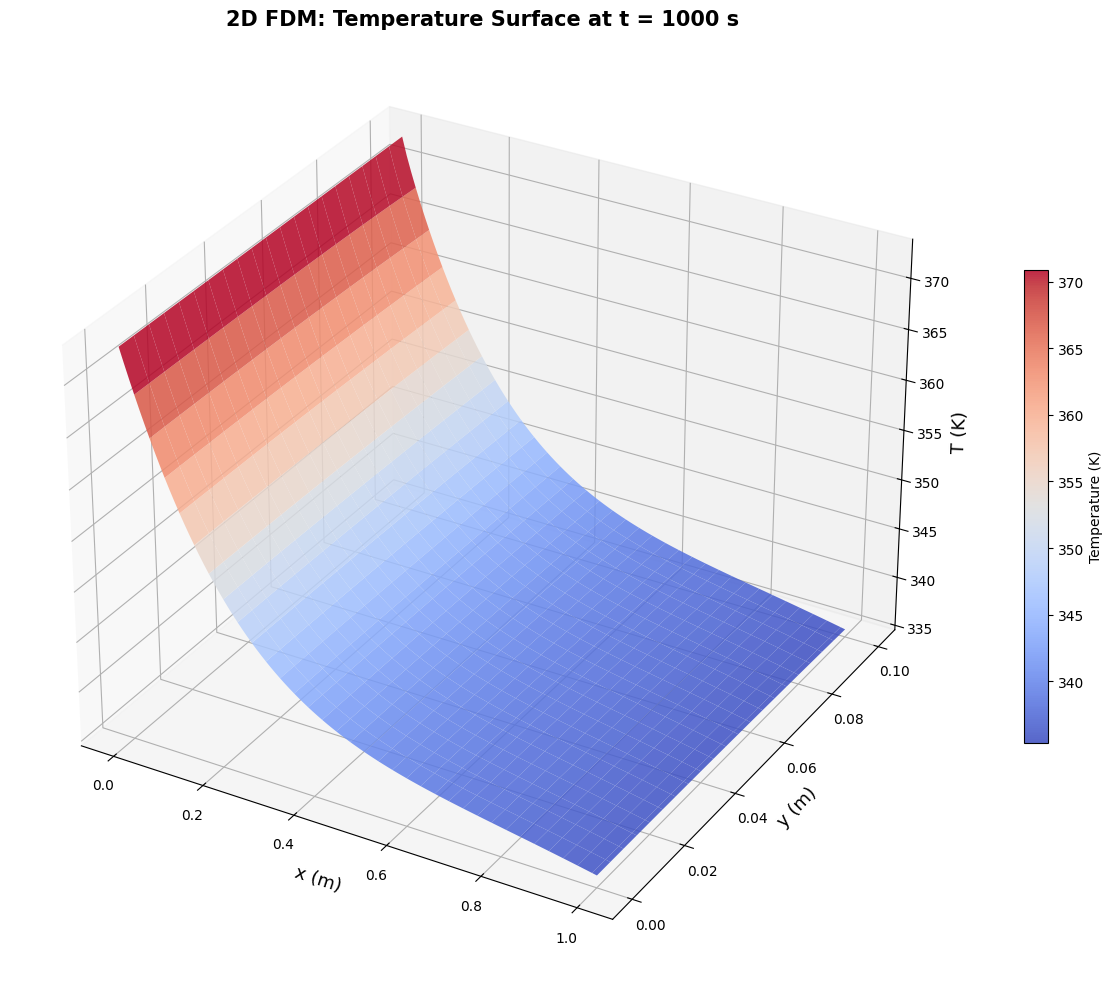


2D FDM HEAT TRANSFER ANALYSIS
Biot number (x)   Bi_x = 0.2500
Biot number (y)   Bi_y = 0.0250
Fourier number    Fo   = 0.08

Final state (t = 1000 s):
  Max temperature        : 373.00 K  (99.85°C)
  Min temperature        : 335.32 K  (62.17°C)
  Average temperature    : 344.75 K  (71.60°C)
  Spatial variation      : 37.68 K
  Fin effectiveness      : 0.6234
  Cooling efficiency     : 37.66%
  Heat flux at tip (x=L, y=0): q = 1841.63 W/m²

PART 3: FDM vs PINN METHOD COMPARISON SCHEMATIC


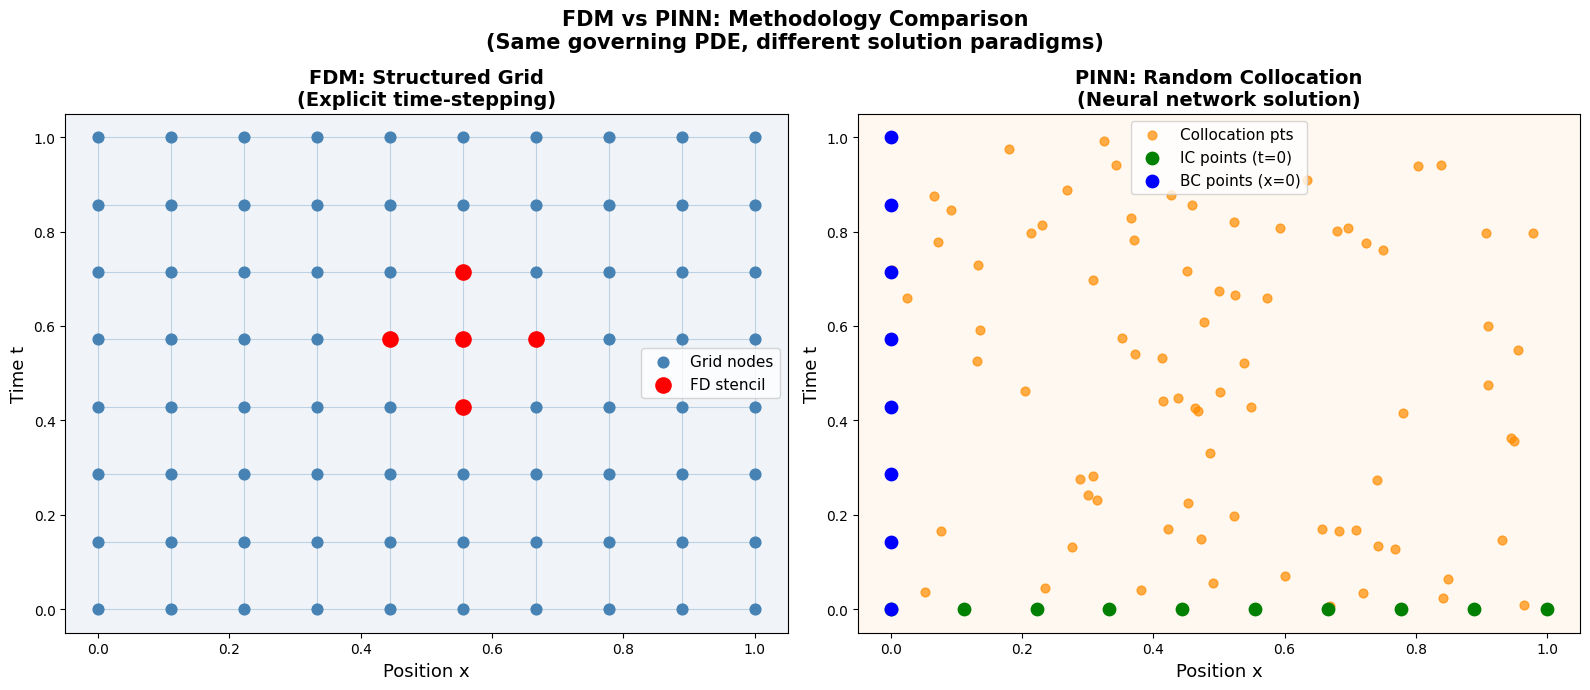


All output files saved:
  1D FDM:
    - fdm_1d_spatial_profiles.png
    - fdm_1d_temporal_evolution.png
    - fdm_1d_heatmap.png
    - fdm_1d_final_state.png
  2D FDM:
    - fdm_2d_contour_snapshots.png
    - fdm_2d_centerline_profiles.png
    - fdm_2d_crosswidth_profiles.png
    - fdm_2d_3d_surface.png
  Comparison:
    - fdm_vs_pinn_comparison.png


In [1]:
# =============================================================================
# Finite Difference Method (FDM) Solver for Cooling Fin Heat Transfer
# =============================================================================
# This script implements an explicit Finite Difference Method (FDM) to solve
# the transient heat conduction PDE for both 1D and 2D aluminum cooling fins.
# FDM discretizes the spatial domain into a structured grid and advances the
# solution in time using explicit time-stepping (Forward Euler in time,
# central differences in space).
#
# This serves as a classical numerical counterpart to the PINN approach,
# solving the same governing physics on the same domain with the same
# physical parameters for direct comparison.
#
# 1D Governing PDE:
#   ρ·cₚ · ∂T/∂t = k · ∂²T/∂x² - h·P · (T - T∞)
#
# 2D Governing PDE:
#   ρ·cₚ · ∂T/∂t = k·(∂²T/∂x² + ∂²T/∂y²) - h·(2/W)·(T - T∞)
#
# Stability:
#   Explicit FDM requires the CFL-like stability condition:
#   1D:  r = α·Δt/Δx² ≤ 0.5
#   2D:  r = α·Δt·(1/Δx² + 1/Δy²) ≤ 0.5
#
# Boundary Conditions:
#   x=0  : T = T_base          (Dirichlet, fixed temperature)
#   x=L  : -k·∂T/∂x = h(T-T∞) (Robin, convective tip)
#   y=0  : ∂T/∂y = 0           (Neumann, symmetry — 2D only)
#   y=W  : -k·∂T/∂y = h(T-T∞) (Robin, convective side — 2D only)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
warnings.filterwarnings('ignore')

# --- Plotting Style ---
plt.style.use('default')
plt.rcParams['figure.dpi']   = 100
plt.rcParams['savefig.dpi']  = 300

# =============================================================================
# SHARED PHYSICAL PARAMETERS (Aluminum Fin)
# =============================================================================
rho    = 2700.0    # Density [kg/m³]
c_p    = 900.0     # Specific heat capacity [J/(kg·K)]
k      = 200.0     # Thermal conductivity [W/(m·K)]
h      = 50.0      # Convective heat transfer coefficient [W/(m²·K)]
T_inf  = 298.0     # Ambient temperature [K]
T_init = 373.0     # Initial uniform temperature [K]
T_base = 373.0     # Fixed base temperature [K]
L      = 1.0       # Fin length [m]
W      = 0.1       # Fin width [m] (2D only)
t_max  = 1000.0    # Total simulation time [s]

# Thermal diffusivity [m²/s]
alpha = k / (rho * c_p)

print("=" * 70)
print("Finite Difference Method — Aluminum Cooling Fin (1D and 2D)")
print("=" * 70)
print(f"Thermal diffusivity α = {alpha:.4e} m²/s")


# =============================================================================
# 1D FDM SOLVER
# =============================================================================
class FDM1DSolver:
    """
    Explicit Finite Difference Method solver for 1D transient fin heat transfer.

    Discretizes x ∈ [0, L] into nx nodes with spacing Δx = L/(nx-1).
    Time is advanced with step Δt chosen to satisfy numerical stability.

    Scheme:
        T_i^{n+1} = T_i^n + Δt·[ α·(T_{i+1} - 2T_i + T_{i-1})/Δx²
                                   - (hP/ρcₚ)·(T_i - T∞) ]

    Boundary nodes use one-sided finite differences for Robin conditions.
    """

    def __init__(self, nx=201, safety_factor=0.4):
        """
        Initialize the 1D FDM solver.

        Args:
            nx            : int   - number of spatial nodes (including boundaries)
            safety_factor : float - multiplier on max stable Δt (< 0.5 for stability)
        """
        self.nx = nx
        self.dx = L / (nx - 1)                       # Spatial step size [m]
        self.x  = np.linspace(0, L, nx)              # Node positions [m]

        # Stability condition: r = α·Δt/Δx² ≤ 0.5
        # Include convective term: effective stability limit is tighter
        self.dt = safety_factor * self.dx**2 / alpha  # Time step [s]
        self.r  = alpha * self.dt / self.dx**2        # Diffusion number (≤ 0.5)

        # Convective decay coefficient [1/s]
        self.beta = h * (2.0 / W) / (rho * c_p)      # Simplified using width

        print(f"\n[1D FDM] Grid: nx={nx}, Δx={self.dx:.4f} m")
        print(f"[1D FDM] Time step: Δt={self.dt:.4f} s, r={self.r:.4f} (stable if <0.5)")

    def solve(self, t_save=None):
        """
        Advance the 1D solution from t=0 to t=t_max using explicit time stepping.

        Args:
            t_save : array-like - time values at which to save the full solution
                     (e.g. [0, 100, 500, 1000]). If None, defaults to 8 snapshots.

        Returns:
            x        : np.array [nx]         - spatial node positions
            T_saves  : np.array [len(t_save), nx] - temperature at saved times
            t_saves  : list - actual times at which solutions were saved
            loss_pde : list - RMS PDE residual tracked over time
        """
        if t_save is None:
            t_save = np.linspace(0, t_max, 9)

        # --- Initialize temperature field ---
        T = T_init * np.ones(self.nx)   # Uniform initial condition
        T[0] = T_base                    # Enforce Dirichlet BC at x=0

        T_saves  = []
        t_saves  = []
        rms_list = []

        n_steps    = int(t_max / self.dt)
        save_steps = set([int(ts / self.dt) for ts in t_save])

        print(f"[1D FDM] Total time steps: {n_steps}")
        start = time.time()

        for n in range(n_steps + 1):
            t_current = n * self.dt

            # --- Save snapshot if at a target time ---
            if n in save_steps or n == 0:
                T_saves.append(T.copy())
                t_saves.append(t_current)

            # --- Compute next time step ---
            T_new = T.copy()

            # Interior nodes: central difference in space, forward in time
            for i in range(1, self.nx - 1):
                d2T_dx2 = (T[i+1] - 2*T[i] + T[i-1]) / self.dx**2
                conv     = self.beta * (T[i] - T_inf)
                T_new[i] = T[i] + self.dt * (alpha * d2T_dx2 - conv)

            # --- Boundary conditions ---
            # Left BC: Dirichlet, T(0, t) = T_base
            T_new[0] = T_base

            # Right BC: Robin (convective tip)
            # Discretized: k·(T[-2] - T[-1])/Δx = h·(T[-1] - T∞)
            # → T[-1] = (k/Δx·T[-2] + h·T∞) / (k/Δx + h)
            T_new[-1] = (k / self.dx * T[-2] + h * T_inf) / (k / self.dx + h)

            # --- Track RMS of PDE residual ---
            res = (T_new[1:-1] - T[1:-1]) / self.dt  # ∂T/∂t approximation
            rms_list.append(float(np.sqrt(np.mean(res**2))))

            T = T_new

        print(f"[1D FDM] Solved in {time.time()-start:.2f}s")
        return self.x, np.array(T_saves), t_saves, rms_list


# =============================================================================
# 2D FDM SOLVER
# =============================================================================
class FDM2DSolver:
    """
    Explicit Finite Difference Method solver for 2D transient fin heat transfer.

    Discretizes the 2D domain (x, y) ∈ [0,L] × [0,W] into a structured
    rectangular grid with nx × ny nodes.

    Scheme (interior nodes):
        T_ij^{n+1} = T_ij^n + Δt·[ α·(T_{i+1,j} - 2T_{ij} + T_{i-1,j})/Δx²
                                    + α·(T_{i,j+1} - 2T_{ij} + T_{i,j-1})/Δy²
                                    - (2h/ρcₚW)·(T_{ij} - T∞) ]

    BCs applied via ghost node / one-sided difference techniques.
    """

    def __init__(self, nx=101, ny=21, safety_factor=0.4):
        """
        Initialize the 2D FDM solver.

        Args:
            nx, ny        : int   - number of nodes in x and y directions
            safety_factor : float - multiplier on max stable Δt for 2D
        """
        self.nx = nx
        self.ny = ny
        self.dx = L / (nx - 1)         # Spatial step in x [m]
        self.dy = W / (ny - 1)         # Spatial step in y [m]
        self.x  = np.linspace(0, L, nx)
        self.y  = np.linspace(0, W, ny)

        # 2D stability: r_x + r_y ≤ 0.5
        max_dt  = safety_factor / (alpha * (1/self.dx**2 + 1/self.dy**2))
        self.dt = max_dt
        self.rx = alpha * self.dt / self.dx**2   # x diffusion number
        self.ry = alpha * self.dt / self.dy**2   # y diffusion number

        # Volumetric convective term [1/s]: from both flat faces (top + bottom)
        self.beta = h * (2.0 / W) / (rho * c_p)

        print(f"\n[2D FDM] Grid: {nx}×{ny}, Δx={self.dx:.4f} m, Δy={self.dy:.5f} m")
        print(f"[2D FDM] Δt={self.dt:.6f} s, rx={self.rx:.4f}, ry={self.ry:.4f}")
        print(f"[2D FDM] Stability parameter rx+ry = {self.rx+self.ry:.4f} (must be <0.5)")

    def solve(self, t_save=None):
        """
        Advance the 2D solution from t=0 to t=t_max.

        Uses vectorized NumPy operations for efficiency (avoids Python loops
        over individual nodes).

        Args:
            t_save : array-like - time values at which to save full 2D fields

        Returns:
            x, y      : node coordinate arrays
            T_saves   : list of 2D arrays T[ny, nx] at each save time
            t_saves   : list of corresponding save times
        """
        if t_save is None:
            t_save = np.linspace(0, t_max, 9)

        # --- Initialize temperature field: T[j, i] = T(x_i, y_j) ---
        T = T_init * np.ones((self.ny, self.nx))   # Uniform initial condition
        T[:, 0] = T_base                            # Dirichlet BC at x=0 (base)

        T_saves  = []
        t_saves  = []

        n_steps    = int(t_max / self.dt)
        save_steps = set([int(ts / self.dt) for ts in t_save])
        # Always save first step
        save_steps.add(0)

        print(f"[2D FDM] Total time steps: {n_steps}")
        start = time.time()

        for n in range(n_steps + 1):
            t_current = n * self.dt

            if n in save_steps:
                T_saves.append(T.copy())
                t_saves.append(t_current)

            T_new = T.copy()

            # --- Interior nodes (vectorized update) ---
            # Slicing: i=1..nx-2, j=1..ny-2
            d2T_dx2 = (T[1:-1, 2:] - 2*T[1:-1, 1:-1] + T[1:-1, :-2]) / self.dx**2
            d2T_dy2 = (T[2:, 1:-1] - 2*T[1:-1, 1:-1] + T[:-2, 1:-1]) / self.dy**2
            conv     = self.beta * (T[1:-1, 1:-1] - T_inf)
            T_new[1:-1, 1:-1] = (T[1:-1, 1:-1]
                                  + self.dt * (alpha * (d2T_dx2 + d2T_dy2) - conv))

            # --- Boundary Conditions ---

            # Left (x=0): Dirichlet — fixed base temperature
            T_new[:, 0] = T_base

            # Right (x=L): Robin — convective tip
            # One-sided FD: k·(T[:,nx-2] - T[:,nx-1])/Δx = h·(T[:,nx-1] - T∞)
            T_new[:, -1] = (k/self.dx * T[:, -2] + h * T_inf) / (k/self.dx + h)

            # Bottom (y=0): Neumann symmetry — ∂T/∂y = 0
            # Ghost node: T[-1] = T[1], so d2T/dy2 uses T[1] for both sides
            T_new[0, :] = T_new[1, :]  # Copy from adjacent row (zero flux)

            # Top (y=W): Robin — convective side
            # One-sided FD: k·(T[ny-2,:] - T[ny-1,:])/Δy = h·(T[ny-1,:] - T∞)
            T_new[-1, :] = (k/self.dy * T[-2, :] + h * T_inf) / (k/self.dy + h)

            # Re-enforce left BC after BC sweeps
            T_new[:, 0] = T_base

            T = T_new

        print(f"[2D FDM] Solved in {time.time()-start:.2f}s")
        return self.x, self.y, T_saves, t_saves


# =============================================================================
# 1D VISUALIZATION
# =============================================================================
def visualize_1d(x, T_saves, t_saves):
    """
    Generate plots for the 1D FDM solution:
        1. Temperature profiles at selected time snapshots
        2. Temporal evolution at fixed positions
        3. Heatmap of T(x, t)
        4. Steady-state temperature distribution

    Args:
        x       : np.array [nx] - spatial positions
        T_saves : np.array [n_saves, nx] - temperature snapshots
        t_saves : list - corresponding time values
    """

    # =========================================================================
    # Figure 1: Spatial Temperature Profiles Over Time
    # =========================================================================
    plt.figure(figsize=(13, 8))
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(t_saves)))

    for i, (T_snap, t_val) in enumerate(zip(T_saves, t_saves)):
        plt.plot(x, T_snap, color=colors[i], linewidth=2.5,
                 label=f't = {t_val:.0f} s')

    plt.axhline(T_inf, color='gray', linestyle='--', linewidth=1.5, label='T∞')
    plt.xlabel('Position x (m)', fontsize=14)
    plt.ylabel('Temperature T (K)', fontsize=14)
    plt.title('1D FDM: Temperature Distribution Along Fin', fontsize=16, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.ylim([290, 380])

    # Secondary Celsius axis
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    ax2.set_ylabel('Temperature (°C)', fontsize=14)
    ax2.set_ylim([T - 273.15 for T in ax1.get_ylim()])

    plt.tight_layout()
    plt.savefig('fdm_1d_spatial_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # Figure 2: Temporal Evolution at Specific Positions
    # =========================================================================
    plt.figure(figsize=(13, 8))

    # Build time array from save times
    t_arr    = np.array(t_saves)
    positions = [0.0, 0.25, 0.5, 0.75, 1.0]   # Fraction of L
    colors2   = plt.cm.viridis(np.linspace(0, 1, len(positions)))

    for ci, frac in enumerate(positions):
        # Find nearest node index
        idx = int(round(frac * (len(x) - 1)))
        T_at_pos = T_saves[:, idx]
        plt.plot(t_arr, T_at_pos, color=colors2[ci], linewidth=2.5,
                 label=f'x = {x[idx]:.2f} m')

    plt.axhline(T_inf, color='red', linestyle='--', linewidth=1.5, label='T∞ = 298 K')
    plt.xlabel('Time t (s)', fontsize=14)
    plt.ylabel('Temperature T (K)', fontsize=14)
    plt.title('1D FDM: Temporal Temperature Evolution at Fixed Positions',
              fontsize=15, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('fdm_1d_temporal_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # Figure 3: Heatmap of T(x, t)
    # =========================================================================
    plt.figure(figsize=(13, 8))

    T_matrix = np.array(T_saves)       # Shape: [n_saves, nx]
    t_arr    = np.array(t_saves)

    im = plt.contourf(x, t_arr, T_matrix,
                      levels=np.linspace(T_inf, T_init, 25),
                      cmap='coolwarm', extend='both')
    ct = plt.contour(x, t_arr, T_matrix, levels=10,
                     colors='black', alpha=0.4, linewidths=0.8)
    plt.clabel(ct, inline=True, fontsize=9, fmt='%.0f K')

    cbar = plt.colorbar(im, shrink=0.9)
    cbar.set_label('Temperature (K)', fontsize=13)
    plt.xlabel('Position x (m)', fontsize=14)
    plt.ylabel('Time t (s)', fontsize=14)
    plt.title('1D FDM: Spatiotemporal Temperature Heatmap', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fdm_1d_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # Figure 4: Steady-State Distribution
    # =========================================================================
    plt.figure(figsize=(12, 7))

    T_ss = T_saves[-1]   # Last saved time ≈ steady state
    plt.plot(x, T_ss, 'b-', linewidth=3, label=f't = {t_saves[-1]:.0f} s (final)')
    plt.fill_between(x, T_inf, T_ss, alpha=0.15, color='blue', label='ΔT above ambient')
    plt.axhline(T_inf, color='red', linestyle='--', linewidth=2, label=f'T∞ = {T_inf} K')

    plt.xlabel('Position x (m)', fontsize=14)
    plt.ylabel('Temperature T (K)', fontsize=14)
    plt.title('1D FDM: Final Temperature Distribution', fontsize=15, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.ylim([290, 380])
    plt.tight_layout()
    plt.savefig('fdm_1d_final_state.png', dpi=300, bbox_inches='tight')
    plt.show()


# =============================================================================
# 2D VISUALIZATION
# =============================================================================
def visualize_2d(x, y, T_saves, t_saves):
    """
    Generate plots for the 2D FDM solution:
        1. 2D contour maps at selected snapshots
        2. Centerline (y=0) profiles over time
        3. Cross-width profiles at selected x
        4. 3D surface at final time

    Args:
        x, y    : np.arrays - node coordinates in x and y
        T_saves : list of 2D arrays [ny, nx]
        t_saves : list of corresponding time values
    """
    X_grid, Y_grid = np.meshgrid(x, y)  # Shape: [ny, nx]

    # =========================================================================
    # Figure 5: 2D Contour Maps at Selected Snapshots
    # =========================================================================
    # Select up to 6 evenly spaced snapshots
    idx_plot = np.linspace(0, len(T_saves) - 1, 6, dtype=int)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for plot_i, snap_i in enumerate(idx_plot):
        T_snap = T_saves[snap_i]
        levels = np.linspace(T_inf, T_init, 25)

        cf = axes[plot_i].contourf(X_grid, Y_grid, T_snap,
                                   levels=levels, cmap='coolwarm', extend='both')
        ct = axes[plot_i].contour(X_grid, Y_grid, T_snap,
                                  levels=8, colors='k', alpha=0.4, linewidths=0.8)
        axes[plot_i].clabel(ct, inline=True, fontsize=7, fmt='%.0f K')
        plt.colorbar(cf, ax=axes[plot_i], label='T (K)')
        axes[plot_i].set_xlabel('x (m)', fontsize=11)
        axes[plot_i].set_ylabel('y (m)', fontsize=11)
        axes[plot_i].set_title(f't = {t_saves[snap_i]:.0f} s',
                               fontsize=13, fontweight='bold')

    fig.suptitle('2D FDM: Temperature Contour Maps\n(Aluminum Cooling Fin)',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fdm_2d_contour_snapshots.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # Figure 6: Centerline Profiles (y=0 → j=0)
    # =========================================================================
    plt.figure(figsize=(13, 8))
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(idx_plot)))

    for ci, snap_i in enumerate(idx_plot):
        T_snap  = T_saves[snap_i]
        T_cl    = T_snap[0, :]    # j=0 row = y=0 (centerline / symmetry plane)
        plt.plot(x, T_cl, color=colors[ci], linewidth=2.5,
                 label=f't = {t_saves[snap_i]:.0f} s')

    plt.axhline(T_inf, color='gray', linestyle='--', linewidth=1.5, label='T∞')
    plt.xlabel('Position x (m)', fontsize=14)
    plt.ylabel('Temperature T (K)', fontsize=14)
    plt.title('2D FDM: Centerline Temperature (y=0)', fontsize=15, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('fdm_2d_centerline_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # Figure 7: Cross-Width Profiles at Selected x Positions (Final Time)
    # =========================================================================
    plt.figure(figsize=(13, 8))

    x_frac   = [0.0, 0.25, 0.5, 0.75, 1.0]
    colors3  = plt.cm.viridis(np.linspace(0, 1, len(x_frac)))
    T_final  = T_saves[-1]    # Final time step

    for ci, frac in enumerate(x_frac):
        i_node  = int(round(frac * (len(x) - 1)))
        T_cross = T_final[:, i_node]          # Column at x_i, all y
        plt.plot(y * 100, T_cross, color=colors3[ci], linewidth=2.5,
                 label=f'x = {x[i_node]:.2f} m')

    plt.xlabel('Width position y (cm)', fontsize=14)
    plt.ylabel('Temperature T (K)', fontsize=14)
    plt.title(f'2D FDM: Cross-Width Profiles at t = {t_saves[-1]:.0f} s',
              fontsize=15, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('fdm_2d_crosswidth_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # Figure 8: 3D Surface of Final Temperature Field T(x, y)
    # =========================================================================
    fig  = plt.figure(figsize=(14, 10))
    ax3d = fig.add_subplot(111, projection='3d')
    T_final = T_saves[-1]

    surf = ax3d.plot_surface(X_grid, Y_grid, T_final, cmap='coolwarm', alpha=0.85)
    ax3d.set_xlabel('x (m)', fontsize=13)
    ax3d.set_ylabel('y (m)', fontsize=13)
    ax3d.set_zlabel('T (K)', fontsize=13)
    ax3d.set_title(f'2D FDM: Temperature Surface at t = {t_saves[-1]:.0f} s',
                   fontsize=15, fontweight='bold')
    fig.colorbar(surf, shrink=0.5, label='Temperature (K)')
    plt.tight_layout()
    plt.savefig('fdm_2d_3d_surface.png', dpi=300, bbox_inches='tight')
    plt.show()


# =============================================================================
# ANALYSIS & REPORTING
# =============================================================================
def analyze_1d(x, T_saves, t_saves):
    """
    Compute and report 1D FDM performance metrics and dimensionless numbers.
    """
    print("\n" + "="*70)
    print("1D FDM HEAT TRANSFER ANALYSIS")
    print("="*70)

    Bi   = h * L / k
    Fo   = alpha * t_max / L**2
    tau  = rho * c_p / (h * 2.0 / W)

    print(f"Biot number       Bi = {Bi:.4f}")
    print(f"Fourier number    Fo = {Fo:.2f}")
    print(f"Time constant     τ  = {tau:.1f} s")

    T_final = T_saves[-1]
    T_avg   = np.mean(T_final)

    print(f"\nFinal state (t = {t_saves[-1]:.0f} s):")
    print(f"  Base temperature (x=0) : {T_final[0]:.2f} K  ({T_final[0]-273.15:.2f}°C)")
    print(f"  Tip temperature  (x=L) : {T_final[-1]:.2f} K  ({T_final[-1]-273.15:.2f}°C)")
    print(f"  Average temperature    : {T_avg:.2f} K  ({T_avg-273.15:.2f}°C)")
    print(f"  Base-to-tip drop       : {T_final[0] - T_final[-1]:.2f} K")
    print(f"  Fin effectiveness      : {(T_avg - T_inf)/(T_base - T_inf):.4f}")
    print(f"  Cooling efficiency     : {(T_init - T_avg)/(T_init - T_inf)*100:.2f}%")


def analyze_2d(x, y, T_saves, t_saves):
    """
    Compute and report 2D FDM performance metrics.
    """
    print("\n" + "="*70)
    print("2D FDM HEAT TRANSFER ANALYSIS")
    print("="*70)

    Bi_x = h * L / k
    Bi_y = h * W / k
    Fo   = alpha * t_max / L**2

    print(f"Biot number (x)   Bi_x = {Bi_x:.4f}")
    print(f"Biot number (y)   Bi_y = {Bi_y:.4f}")
    print(f"Fourier number    Fo   = {Fo:.2f}")

    T_final = T_saves[-1]
    T_avg   = np.mean(T_final)
    T_min   = np.min(T_final)
    T_max_f = np.max(T_final)

    print(f"\nFinal state (t = {t_saves[-1]:.0f} s):")
    print(f"  Max temperature        : {T_max_f:.2f} K  ({T_max_f-273.15:.2f}°C)")
    print(f"  Min temperature        : {T_min:.2f} K  ({T_min-273.15:.2f}°C)")
    print(f"  Average temperature    : {T_avg:.2f} K  ({T_avg-273.15:.2f}°C)")
    print(f"  Spatial variation      : {T_max_f - T_min:.2f} K")
    print(f"  Fin effectiveness      : {(T_avg - T_inf)/(T_base - T_inf):.4f}")
    print(f"  Cooling efficiency     : {(T_init - T_avg)/(T_init - T_inf)*100:.2f}%")

    # 2D gradient at centerline tip (approximate heat flux at x=L, y=0)
    dx      = x[1] - x[0]
    dT_dx_tip = (T_final[0, -1] - T_final[0, -2]) / dx
    q_tip   = -k * dT_dx_tip
    print(f"  Heat flux at tip (x=L, y=0): q = {q_tip:.2f} W/m²")


# =============================================================================
# COMPARATIVE PLOT: 1D FDM vs 1D PINN (if PINN data available)
# =============================================================================
def plot_method_comparison_schematic():
    """
    Generate a schematic comparison plot illustrating the key conceptual
    differences between FDM and PINN approaches for the same problem.

    This visualization summarizes the solution methodology rather than
    showing numerically equivalent results side-by-side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # --- FDM schematic: structured grid ---
    ax_fdm = axes[0]
    nx_demo, nt_demo = 10, 8
    x_demo = np.linspace(0, 1, nx_demo)
    t_demo = np.linspace(0, 1, nt_demo)
    Xd, Td = np.meshgrid(x_demo, t_demo)
    ax_fdm.scatter(Xd, Td, c='steelblue', s=60, zorder=3, label='Grid nodes')

    # Draw grid lines
    for i in range(nt_demo):
        ax_fdm.plot(x_demo, t_demo[i] * np.ones_like(x_demo),
                    'steelblue', alpha=0.3, linewidth=0.8)
    for j in range(nx_demo):
        ax_fdm.plot(x_demo[j] * np.ones_like(t_demo), t_demo,
                    'steelblue', alpha=0.3, linewidth=0.8)

    # Highlight stencil
    ci, cj = 5, 4
    stencil_x = [x_demo[ci-1], x_demo[ci], x_demo[ci+1], x_demo[ci], x_demo[ci]]
    stencil_t = [t_demo[cj], t_demo[cj], t_demo[cj], t_demo[cj-1], t_demo[cj+1]]
    ax_fdm.scatter(stencil_x, stencil_t, c='red', s=120, zorder=4, label='FD stencil')

    ax_fdm.set_xlabel('Position x', fontsize=13)
    ax_fdm.set_ylabel('Time t', fontsize=13)
    ax_fdm.set_title('FDM: Structured Grid\n(Explicit time-stepping)',
                     fontsize=14, fontweight='bold')
    ax_fdm.legend(fontsize=11)
    ax_fdm.set_facecolor('#f0f4f8')

    # --- PINN schematic: random collocation points ---
    ax_pinn = axes[1]
    np.random.seed(7)
    n_rand = 80
    xr = np.random.uniform(0, 1, n_rand)
    tr = np.random.uniform(0, 1, n_rand)
    ax_pinn.scatter(xr, tr, c='darkorange', s=40, alpha=0.7, label='Collocation pts')

    # Highlight a few boundary/IC points
    x_ic  = np.linspace(0, 1, 10)
    ax_pinn.scatter(x_ic, np.zeros_like(x_ic), c='green', s=80,
                    zorder=4, label='IC points (t=0)')
    ax_pinn.scatter(np.zeros(8), np.linspace(0, 1, 8), c='blue',
                    s=80, zorder=4, label='BC points (x=0)')

    ax_pinn.set_xlabel('Position x', fontsize=13)
    ax_pinn.set_ylabel('Time t', fontsize=13)
    ax_pinn.set_title('PINN: Random Collocation\n(Neural network solution)',
                      fontsize=14, fontweight='bold')
    ax_pinn.legend(fontsize=11)
    ax_pinn.set_facecolor('#fff8f0')

    fig.suptitle('FDM vs PINN: Methodology Comparison\n(Same governing PDE, different solution paradigms)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fdm_vs_pinn_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


# =============================================================================
# MAIN
# =============================================================================
def main():
    """
    Run both 1D and 2D FDM solvers, generate all visualizations,
    report performance metrics, and produce a method comparison schematic.
    """
    print("\n" + "="*70)
    print("PART 1: 1D FINITE DIFFERENCE SOLVER")
    print("="*70)

    # Define save times for 1D
    t_save_1d = np.array([0, 100, 200, 300, 400, 500, 700, 900, 1000])

    # Initialize and run 1D solver
    solver_1d = FDM1DSolver(nx=201, safety_factor=0.4)
    x1d, T_saves_1d, t_saves_1d, rms_1d = solver_1d.solve(t_save=t_save_1d)

    # Visualize 1D results
    print("\nGenerating 1D visualizations...")
    visualize_1d(x1d, T_saves_1d, t_saves_1d)

    # Analyze 1D results
    analyze_1d(x1d, T_saves_1d, t_saves_1d)

    print("\n" + "="*70)
    print("PART 2: 2D FINITE DIFFERENCE SOLVER")
    print("="*70)

    # Define save times for 2D (fewer due to smaller t_max for 2D stability)
    # Using same t_max = 1000 s, but 2D has much smaller Δt → more steps
    t_save_2d = np.linspace(0, t_max, 9)

    # Initialize and run 2D solver (coarser grid for speed)
    solver_2d = FDM2DSolver(nx=101, ny=21, safety_factor=0.4)
    x2d, y2d, T_saves_2d, t_saves_2d = solver_2d.solve(t_save=t_save_2d)

    # Visualize 2D results
    print("\nGenerating 2D visualizations...")
    visualize_2d(x2d, y2d, T_saves_2d, t_saves_2d)

    # Analyze 2D results
    analyze_2d(x2d, y2d, T_saves_2d, t_saves_2d)

    print("\n" + "="*70)
    print("PART 3: FDM vs PINN METHOD COMPARISON SCHEMATIC")
    print("="*70)
    plot_method_comparison_schematic()

    print("\nAll output files saved:")
    print("  1D FDM:")
    print("    - fdm_1d_spatial_profiles.png")
    print("    - fdm_1d_temporal_evolution.png")
    print("    - fdm_1d_heatmap.png")
    print("    - fdm_1d_final_state.png")
    print("  2D FDM:")
    print("    - fdm_2d_contour_snapshots.png")
    print("    - fdm_2d_centerline_profiles.png")
    print("    - fdm_2d_crosswidth_profiles.png")
    print("    - fdm_2d_3d_surface.png")
    print("  Comparison:")
    print("    - fdm_vs_pinn_comparison.png")


if __name__ == "__main__":
    main()